In [ ]:
from datasets import load_dataset
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import tqdm
import math

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
ds = load_dataset("Godseye1311/gravitational-waves-strain")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/128 [00:00<?, ?it/s]

gwe-shard-00000.parquet:   0%|          | 0.00/57.1M [00:00<?, ?B/s]

gwe-shard-00001.parquet:   0%|          | 0.00/57.3M [00:00<?, ?B/s]

gwe-shard-00002.parquet:   0%|          | 0.00/57.7M [00:00<?, ?B/s]

...

gwe-shard-00124.parquet:   0%|          | 0.00/57.3M [00:00<?, ?B/s]

gwe-shard-00125.parquet:   0%|          | 0.00/57.4M [00:00<?, ?B/s]

gwe-shard-00126.parquet:   0%|          | 0.00/57.3M [00:00<?, ?B/s]

gwe-shard-00127.parquet:   0%|          | 0.00/57.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/131072 [00:00<?, ? examples/s]

In [3]:
def prepare_data(example):
    h_noisy = np.array(np.log(example['hNoisy']))  # Input: (length,)
    params = np.array([np.log(example['M1']), np.log(example['M2']), np.log(example['R'])])

    # Normalize strain to [-1,1] per sequence (important for CNNs)

    return {
        'input': torch.tensor(h_noisy).unsqueeze(0),  # Shape: (1, length)
        'target': torch.tensor(np.log(params))               # Shape: (3,)
    }

train_ds = ds['train'].map(prepare_data).with_format("torch")


Map:   0%|          | 0/131072 [00:00<?, ? examples/s]

In [4]:
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

In [5]:
class GWCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=8, stride=2, padding=3), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=6, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(8)  # Fixed output size
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*8, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 3)  # M1, M2, R outputs
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.fc_layers(x)

In [6]:
device = torch.device('cuda')
print(device)

model = GWCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()
scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

for epoch in range(100):
    model.train()
    total_loss = 0
    progress_bar = tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for batch in progress_bar:
        inputs = batch['input'].to(device)
        targets = batch['target'].to(device)

        optimizer.zero_grad()
        preds = model(inputs)
        loss = criterion(preds, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    scheduler.step(avg_loss)
    print(f"Epoch {epoch+1}: Loss = {avg_loss:.6f}, LR = {optimizer.param_groups[0]['lr']:.2e}")

cuda


Epoch 1: 100%|██████████| 1024/1024 [10:12<00:00,  1.67it/s]


Epoch 1: Loss = 0.367912, LR = 1.00e-03


Epoch 2: 100%|██████████| 1024/1024 [09:58<00:00,  1.71it/s]


Epoch 2: Loss = 0.051310, LR = 1.00e-03


...

Epoch 19: Loss = 0.000062, LR = 1.00e-03


Epoch 20: 100%|██████████| 1024/1024 [10:09<00:00,  1.68it/s]


Epoch 20: Loss = 0.000059, LR = 1.00e-03


Epoch 21:  60%|█████▉    | 613/1024 [06:02<04:03,  1.69it/s]


KeyboardInterrupt: 

In [7]:
def simulate_waveforms(m1, m2, r, tmax, n_samples=4096, noise_std=0.01):
    G = 6.6743e-11
    c = 299792458

    chirp_mass = (m1*m2)**(3/5) / (m1 + m2)**(1/5)
    K = (96/5) * (math.pow(G, 5/3)) * math.pow(chirp_mass, 5/3)

    omega0 = math.sqrt(G * chirp_mass / math.pow(r, 3))
    tc = (3/(8*K)) * math.pow(omega0, -8/3)
    t = np.linspace(0, min(tc, tmax), n_samples)

    omega = math.pow(8*K/3, -3/8) * (tc - t)
    phi = np.cumsum(omega * (t[1]-t[0]))
    h = (4*G*chirp_mass/(math.pow(c, 2)*r)) * np.power(omega * chirp_mass/2, 2/3) * np.cos(2 * phi)

    noise = np.random.normal(0, noise_std, size=h.shape)
    return t, h, h + noise

In [155]:
def sample_parameters():
    m1 = np.random.uniform(1, 100) * 1.98847e30
    m2 = np.random.uniform(1, 100) * 1.98847e30
    r  = np.random.uniform(3e17, 5e17)  # 1e8–1e11 m
    return m1, m2, r

In [156]:
M1, M2, R = sample_parameters()
t, h, h_noisy = simulate_waveforms(M1, M2, R, tmax=1, noise_std=1e-12, n_samples=128)

In [157]:
model.eval()
h_noisy = np.array(np.log(h_noisy), dtype=np.float32)
inputs = torch.tensor(h_noisy).unsqueeze(0).unsqueeze(0).to(device)
output = model(inputs)

In [158]:
pred_M1 = np.exp(np.exp(output.flatten()[0].cpu().detach().numpy()))
pred_M2 = np.exp(np.exp(output.flatten()[1].cpu().detach().numpy()))
pred_R = np.exp(np.exp(output.flatten()[2].cpu().detach().numpy()))

In [153]:
M1, M2, R

(1.2829096540691086e+32, 7.349829698673681e+31, 3.3320356188719885e+17)

In [154]:
pred_M1, pred_M2, pred_R

(np.float32(1.31568045e+32),
 np.float32(1.3106412e+32),
 np.float32(3.37179e+17))

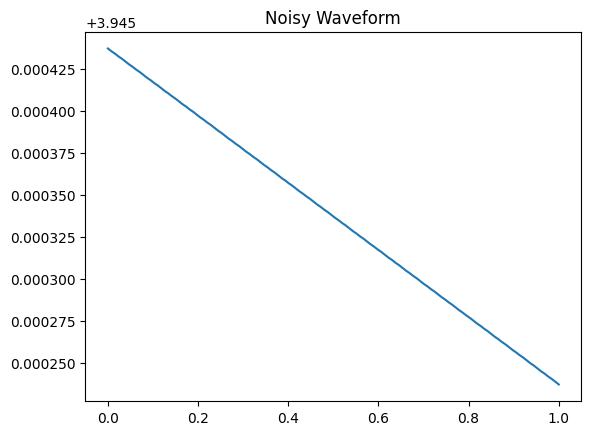

In [137]:
plt.plot(t, h_noisy)
plt.title("Noisy Waveform")
plt.show()